In [1]:
import pandas as pd
import numpy as np
import random
from deap import base, creator, tools, algorithms
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
# load the processed dataset

df = pd.read_excel('./processed_data/noise_imputed_data.xlsx')
df.set_index('Year', inplace=True)

# define target variable and features
y = df['pollinators_mean_occupancy'].values


X_df = df.drop(columns=[
    'pollinators_mean_occupancy', 
])

X = X_df.values
feature_names = X_df.columns.tolist()
NUM_FEATURES = len(feature_names)

In [36]:
# setup the genetic algorithm using DEAP

# minimize the negative mean cross-validated R^2 score
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# define chromosomes as a list of binary valies
toolbox = base.Toolbox()

# randomly assign values to each gene
toolbox.register("attr_bool", random.randint, 0, 1)

# create an individual and a population of individuals
def create_individual():
    # let GA optimise the start and end years 
    start_year = random.randint(1980, 2015)
    end_year = random.randint(2016, 2024)

    if start_year >= end_year:
        start_year, end_year = end_year - 1, start_year + 1
    
    features = [random.randint(0, 1) for _ in range(NUM_FEATURES)]
    # features = [1 for _ in range(NUM_FEATURES)] # start with all features included, and let the GA remove them if they are not useful
    return creator.Individual([start_year, end_year] + features)

toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

c:\Users\szila\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\szila\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [37]:
# At this point, individuals look like this: 
# [start_year, end_year, feature1_included, feature2_included, ..., featureN_included]


In [38]:
# create evaluation function for finding the best feature subset

def evaluate_feature_subset(individual):
    start_year, end_year = individual[0], individual[1]
    feature_flags = individual[2:]

    # decode the chromosome to get selected feature indices
    selected_indices = [i for i in range(NUM_FEATURES) if feature_flags[i] == 1]

    if len(selected_indices) < 5:
        return (9999.0,) # Penalize if fewer than 5 features are selected
    
    # penalty if the GA tries to drop ALL features (invalid model)
    if len(selected_indices) == 0:
        return (9999.0,) # Return a massive error to kill off this chromosome
    
    # same for invalid years ranges
    if start_year >= end_year:
        return (9999.0,)
    
    # temporal slice
    mask = (df.index >= start_year) & (df.index <= end_year)
    X_masked = X_df.loc[mask, feature_names]
    y_masked = y[mask]

    if X_masked.isnull().any().any():
        # drop columns with missing values in the masked dataset
        cols_with_na = X_masked.columns[X_masked.isnull().any()]
        X_masked = X_masked.drop(columns=cols_with_na)
        selected_indices = [i for i in selected_indices if feature_names[i] not in cols_with_na]

        # set the feature flags to 0 for dropped features
        for i in range(NUM_FEATURES):
            if feature_names[i] in cols_with_na:
                feature_flags[i] = 0

    # Create SVR model pipeline with feature scaling
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
    ])
    
    # 5 fold cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # get negative mean squared error scores and convert to RMSE
    try:
        scores = cross_val_score(model, X_masked, y_masked, cv=cv, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-scores.mean())
    except:
        return (9999.0,)
    
    # add a small penalty for every feature used.
    penalty_weight = 0.01

    num_years_captured = end_year - start_year
    
    # Fitness = RMSE - (reward for long timelines) + (penalty for too many features)
    fitness_score = rmse - (0.15 * num_years_captured) + (penalty_weight * len(selected_indices))

    
    return (fitness_score,)

# Register the evaluation function
toolbox.register("evaluate", evaluate_feature_subset)

In [39]:
# need a custom mutation function to ensure valid year ranges
def custom_mutate(individual, indpb):
    # 30% chance to mutate the years
    if random.random() < indpb:
        individual[0] = random.randint(1980, 2023)
    if random.random() <indpb:
        individual[1] = random.randint(1980, 2024)
    # mutate features normally
    for i in range(2, len(individual)):
        if random.random() < indpb:
            individual[i] = type(individual[i])(not individual[i])
    return individual,

In [40]:
# uniform crossover 50% chance of swapping each gene
toolbox.register("mate", tools.cxUniform, indpb=0.5)

toolbox.register("mutate", custom_mutate, indpb=0.1)

# picks the best randomly chosen individuals
toolbox.register("select", tools.selTournament, tournsize=3)

In [41]:

print("Initializing Genetic Algorithm")

# create initial population
pop = toolbox.population(n=50)

# HOF keeps track of the absolute best individual across all generations
hof = tools.HallOfFame(1)

# # stats to print to console during the run
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)

pop, log = algorithms.eaSimple(pop, 
                                toolbox, 
                                cxpb=0.5, 
                                mutpb=0.2, 
                                ngen=50,
                               stats=stats, 
                                halloffame=hof, 
                                verbose=True)

# results
best_ind = hof[0]
print("\n" + "="*40)
print("OPTIMIZATION COMPLETE")
print("="*40)
print(f"Best Fitness Score (RMSE + Penalty): {best_ind.fitness.values[0]:.4f}")

print("\nOptimized Feature Subset:")
selected_features = []
for i in range(NUM_FEATURES):
    if best_ind[i] == 1:
        selected_features.append(feature_names[i])
        print(f"  [X] {feature_names[i]}")
    else:
        print(f"  [ ] {feature_names[i]}")
        
print(f"\nTotal Features Kept: {len(selected_features)} out of {NUM_FEATURES}")
print(f"Dimensionality Reduction: {100 - (len(selected_features)/NUM_FEATURES)*100:.1f}%")
    

Initializing Genetic Algorithm
gen	nevals	avg    	min   
0  	50    	205.619	1.7688
1  	24    	404.865	0.847525
2  	14    	3.80688	0.847525
3  	37    	2.72641	0.66733 
4  	30    	801.468	0.66733 
5  	27    	1.17134	0.66733 
6  	29    	600.906	0.66733 
7  	36    	1800.64	0.66733 
8  	28    	600.894	0.66733 
9  	37    	600.572	0.66733 
10 	31    	0.66733	0.65733 
11 	38    	400.726	0.571641
12 	33    	200.627	0.571641
13 	24    	0.643364	0.571641
14 	34    	400.538 	0.561641
15 	37    	0.572041	0.561641
16 	37    	0.592729	0.561641
17 	36    	0.641271	0.561641
18 	28    	0.567641	0.561641
19 	29    	400.518 	0.561641
20 	31    	200.643 	0.561641
21 	35    	0.665262	0.561641
22 	33    	600.49  	0.561641
23 	31    	200.58  	0.561641
24 	37    	400.524 	0.561641
25 	31    	0.594233	0.561641
26 	32    	600.469 	0.561641
27 	31    	200.535 	0.561641
28 	30    	600.468 	0.561641
29 	28    	0.592059	0.561641
30 	34    	0.561641	0.561641
31 	29    	200.531 	0.561641
32 	39    	0.562641	0.561641
3

In [42]:
best_ind

[1981, 1997, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1]

<Axes: >

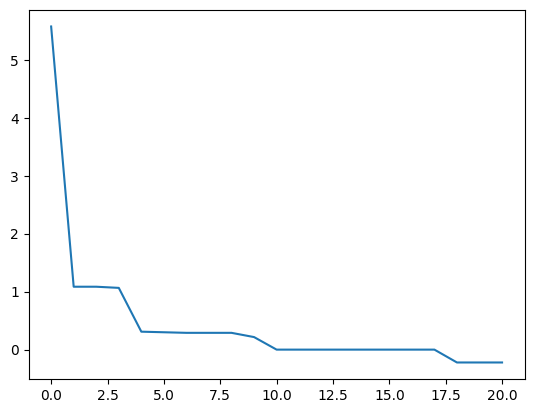

In [15]:

min_log = log.select("min")
import seaborn as sns

sns.lineplot(x=range(len(min_log)), y=min_log)

In [6]:
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

# 5-Fold Cross Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = cross_val_score(baseline_model, X, y, cv=cv, scoring='neg_mean_squared_error')
baseline_rmse = np.sqrt(-baseline_scores.mean())

print(f"Total Features Used: {NUM_FEATURES}")
print(f"Baseline Cross-Validated RMSE: {baseline_rmse:.4f}")


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\szila\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\szila\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\szila\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\szila\AppData\Local\Program